             Electricity Purchase Natural Gas Import Electricity Sales  \
Scenario                                                                 
Baseline                -5.869176          -3.482543         20.022432   
NoStorageCO2            -5.966192          -3.483729         20.010622   
NoStorageALL            -6.217426          -3.489924         19.732903   
H2                      -6.977131          -3.482436         19.170193   
BioFixed                -6.603312          -6.811959         19.189976   
CO2Trans                -5.871078          -3.482568         20.024672   

              Hydrogen Sales O&M Wind Turbine O&M Digester O&M Biogas Upgrade  \
Scenario                                                                        
Baseline            0.000000        -2.402883    -3.769006          -2.142857   
NoStorageCO2        0.000000        -2.402422    -3.769006          -2.142857   
NoStorageALL        0.000000         -2.40143    -3.769006          -2.142857   
H2

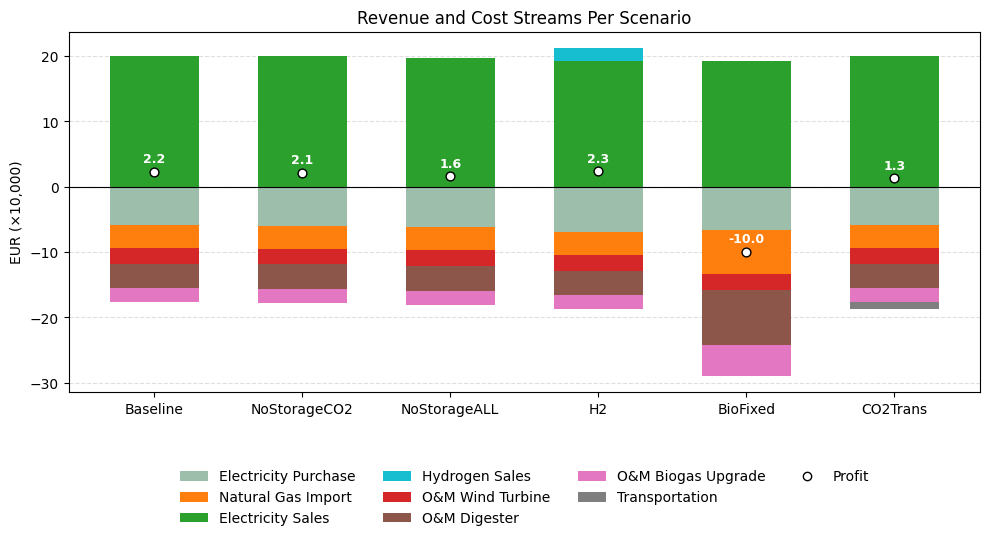

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import patheffects as pe
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

file = '../Scenario_Analysis_NEWEST.xlsx'

# --- Load and shape data ---
df = pd.read_excel(file, sheet_name='ObjFunc')

# first 6 scenarios, set Scenario as index
df = df.iloc[:6].set_index('Scenario')

# keep only from Buy_Electricity to Total Profit (adjust first col name if needed)
df = df.loc[:, 'Buy_Electricity':'Total Profit']

# remove columns that dont contribute much
remove_cols = ['Variable_OM_ElectricStorage', 'Variable_OM_Boiler']
df = df.drop(columns=remove_cols)

# rename columns
df = df.rename(columns={
    'Buy_Electricity': 'Electricity Purchase',
    'Buy_NatGas Import': 'Natural Gas Import',
    'Sell_Electricity': 'Electricity Sales',
    'Sell_H2': 'Hydrogen Sales',
    'Variable_OM_WindTurbine': 'O&M Wind Turbine',
    'Variable_OM_Digester': 'O&M Digester',
    'Variable_OM_BiogasUpgrade': 'O&M Biogas Upgrade',
    'Variable_OM_CO2Compressor': 'Transportation',
    'Total Profit': 'Profit'
})

profit_col = 'Profit'
bar_cols = [c for c in df.columns if c != profit_col]

# scaling for nicer units
scale = 100000
df_plot = df / scale

print(df_plot)


colors = {
    'Electricity Purchase':      "#9cbeaa",
    'Natural Gas Import':        '#ff7f0e',
    'Electricity Sales':         '#2ca02c',
    'Hydrogen Sales':            '#17becf',
    'O&M Wind Turbine':          '#d62728',
    'O&M Digester':              '#8c564b',
    'O&M Biogas Upgrade':        '#e377c2',
    'Transportation':            '#7f7f7f',
}


# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(df_plot))
width = 0.6

used_labels = set()

for i, (scenario, row) in enumerate(df_plot.iterrows()):
    bottom_pos = 0
    bottom_neg = 0

    for col in bar_cols:
        value = row[col]
        if value == 0:
            continue

        # label only the first non-zero occurrence of each column
        label = col if col not in used_labels else None

        if value > 0:
            ax.bar(
                x[i],
                value,
                width,
                bottom=bottom_pos,
                label=label,
                color=colors[col]
            )
            bottom_pos += value
        else:
            ax.bar(
                x[i],
                value,
                width,
                bottom=bottom_neg,
                label=label,
                color=colors[col]
            )
            bottom_neg += value

        if label is not None:
            used_labels.add(col)

    # profit marker + label
    profit = row[profit_col]
    ax.scatter(x[i], profit, s=40, facecolor="white", edgecolor="black", zorder=3)
    ax.text(
        x[i], 
        profit + 1,        # move slightly higher
        f"{profit:.1f}",
        ha="center",
        va="bottom",
        fontsize=9,         # bigger text
        fontweight='bold',
        color="white"        # or any color you want
    )


ax.set_xticks(x)
ax.set_xticklabels(df_plot.index)

ax.set_ylabel("EUR (×10,000)")
ax.set_title("Revenue and Cost Streams Per Scenario")

ax.axhline(0, color="black", linewidth=0.8)
ax.yaxis.grid(True, linestyle="--", alpha=0.4)
ax.set_axisbelow(True)

plt.rcParams["font.size"] = 10
plt.rcParams["axes.labelsize"] = 10
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10
plt.rcParams["legend.fontsize"] = 10


# Desired order of bar entries (8 items → 4 columns × 2 rows)
bar_order = [
    "Electricity Purchase",
    "Natural Gas Import",
    "Electricity Sales",
    "Hydrogen Sales",
    "O&M Wind Turbine",
    "O&M Digester",
    "O&M Biogas Upgrade",
    "Transportation",
]

# One legend handle per bar type (using the same colors)
bar_handles = [
    Patch(facecolor=colors[label], label=label)
    for label in bar_order
]

# Dedicated Profit handle (dot only for legend)
profit_handle = Line2D(
    [], [],
    marker='o',
    linestyle='None',
    markersize=6,
    markerfacecolor='white',
    markeredgecolor='black'
)

# Invisible handle for empty slots
empty_handle = Line2D([], [], linestyle="")

# Layout with ncol=4 and 3 rows:
# row 1: first 4 bar entries
# row 2: next 4 bar entries
# row 3: [empty, Profit, empty, empty]
final_handles = (
    bar_handles +
    [empty_handle, profit_handle, empty_handle, empty_handle]
)
final_labels = (
    bar_order +
    ["", "Profit", "", ""]
)

ax.legend(
    final_handles,
    final_labels,
    bbox_to_anchor=(0.5, -0.18),
    loc="upper center",
    ncol=4,
    frameon=False
)

fig.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig("rev_cost_streams.pdf", bbox_inches="tight")
plt.show()
